Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  obj

/var/folders/__/pn5kx9bj2szdqpyrgp8rkfsr0000gn/T/ipykernel_6385/664015183.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')


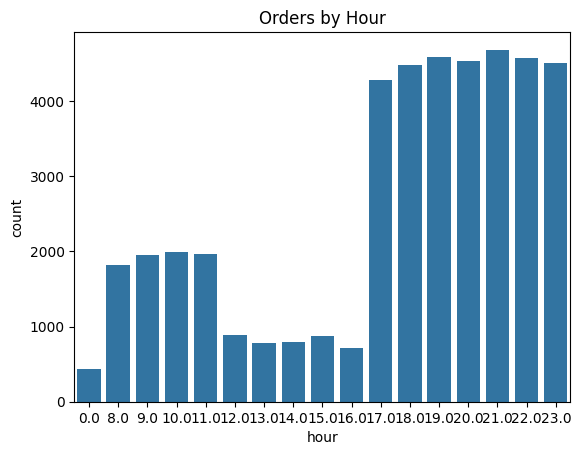

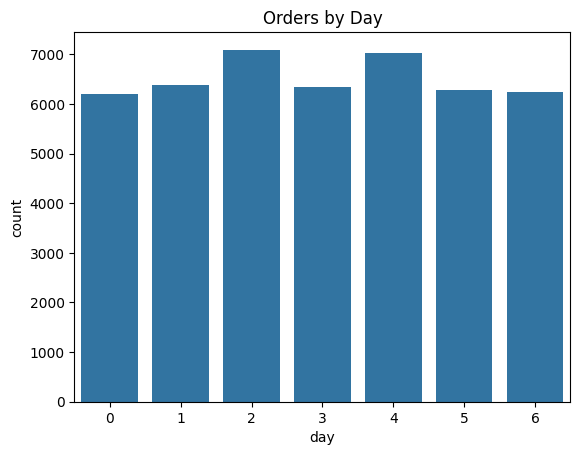

Mean Squared Error: 71.71604890744699
71.71604890744699


In [8]:
%pip install scikit-learn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Data/orders.csv')
df.head()

df.info()
df.describe()

df.isnull().sum()

df = df.dropna()

df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')

df['hour'] = df['Time_Orderd'].dt.hour

df['day'] = df['Order_Date'].dt.dayofweek

sns.countplot(x='hour', data=df)
plt.title("Orders by Hour")
plt.show()

sns.countplot(x='day', data=df)
plt.title("Orders by Day")
plt.show()

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

df['Time_taken(min)'] = df['Time_taken(min)'].str.extract('(\d+)').astype(float)

X = df[['hour', 'day']]
y = df['Time_taken(min)']   

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, preds))

print(mean_squared_error(y_test, preds))

df.to_csv('Data/cleaned_data.csv', index=False)
